In [1]:
import pandas as pd
from kiwipiepy import Kiwi
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
df = pd.read_csv('네이버LG감성분석.csv', encoding='utf-8-sig')
print(df.shape)
print(df['sentiment'].value_counts())
df.head()

(4924, 7)
sentiment
positive    4509
neutral      139
negative      76
Name: count, dtype: int64


,score,sentiment,reason,product_id,product_name,price,clean_review
0,5.0,positive,"매우 가볍고 성능에 만족하며, 사은품과 할인 혜택에 대한 높은 만족도 표현.",11288287015,LG그램 16 인텔 루나레이크 U5,2480000,일단 가볍습니다 이렇게 가벼운 노트북은 처음 써보느지라 7년전에 산 레노바 노트북을...
1,5.0,positive,"제품의 디자인, 속도, 가격, 이벤트 혜택 모두 매우 만족하며 주변에 적극 추천.",11288287015,LG그램 16 인텔 루나레이크 U5,2480000,경단녀 취업을 하며 개인 노트북이 필요해서 인생 첫 노트북을 그것도 그램으로 구매했...
2,5.0,positive,"가벼움, 디자인, 성능, 화면 화질 등 모든 면에서 높은 만족도를 보이며 강력히 추천.",11288287015,LG그램 16 인텔 루나레이크 U5,2480000,그램이 좋은 이유 1 가볍다 2 예쁘고 세련됐다 3 성능이 좋다 이 중 2가지는 알...
3,2.0,negative,"두 번의 오배송과 사은품 누락으로 인한 불만이 크며, 제품의 장점보다 부정적 경험이...",11288287015,LG그램 16 인텔 루나레이크 U5,2480000,워홀가려고 노트북사려고해서 가벼운 그램을 사게되었습니다 설날에 라이브보고 구매했는데...
4,5.0,positive,"빠른 배송, 사은품 제공, 할인 혜택으로 저렴하게 구매하여 매우 만족.",11288287015,LG그램 16 인텔 루나레이크 U5,2480000,어제 라이브중 구매했는데 오늘 바로 와서 너무좋아요 사은품도 챙겨주시고 라이브 할인...


In [5]:
import re
from collections import Counter

stopwords = {
    '것', '수', '제', '좀', '게', '거', '때', '건', '등', '및',
    '이', '그', '저', '걸', '를', '은', '는', '가', '을', '의',
    '도', '로', '에', '과', '와', '한', '하', '있', '없', '더',
    '많', '잘', '안', '못', '나', '내', '제품', '노트북', '합니다',
    '있어', '없어', '해서', '하고', '이고', '인데', '같아', '같은',
    '정도', '근데', '그냥', '어서', '으로', '에서', '부터', '까지'
}

def extract_words(texts):
    all_words = []
    for text in texts:
        if pd.isna(text):
            continue
        # 한글만 추출
        words = re.findall(r'[가-힣]{2,}', str(text))
        filtered = [w for w in words if w not in stopwords]
        all_words.extend(filtered)
    return Counter(all_words)

In [6]:
positive_texts = df[df['sentiment'] == 'positive']['clean_review']
negative_texts = df[df['sentiment'] == 'negative']['clean_review']

print("긍정 단어 추출 중...")
positive_counter = extract_words(positive_texts)

print("부정 단어 추출 중...")
negative_counter = extract_words(negative_texts)

print("긍정 상위 10개:", positive_counter.most_common(10))
print("부정 상위 10개:", negative_counter.most_common(10))

긍정 단어 추출 중...
부정 단어 추출 중...
긍정 상위 10개: [('너무', 1210), ('가볍고', 1063), ('좋아요', 788), ('그램', 557), ('빠르고', 512), ('좋습니다', 502), ('만족합니다', 420), ('정말', 402), ('가벼워서', 386), ('좋은', 379)]
부정 상위 10개: [('너무', 12), ('있습니다', 11), ('키보드', 8), ('다만', 8), ('가볍고', 7), ('같아요', 7), ('구매', 7), ('윈도우', 7), ('그래도', 6), ('좋아요', 6)]


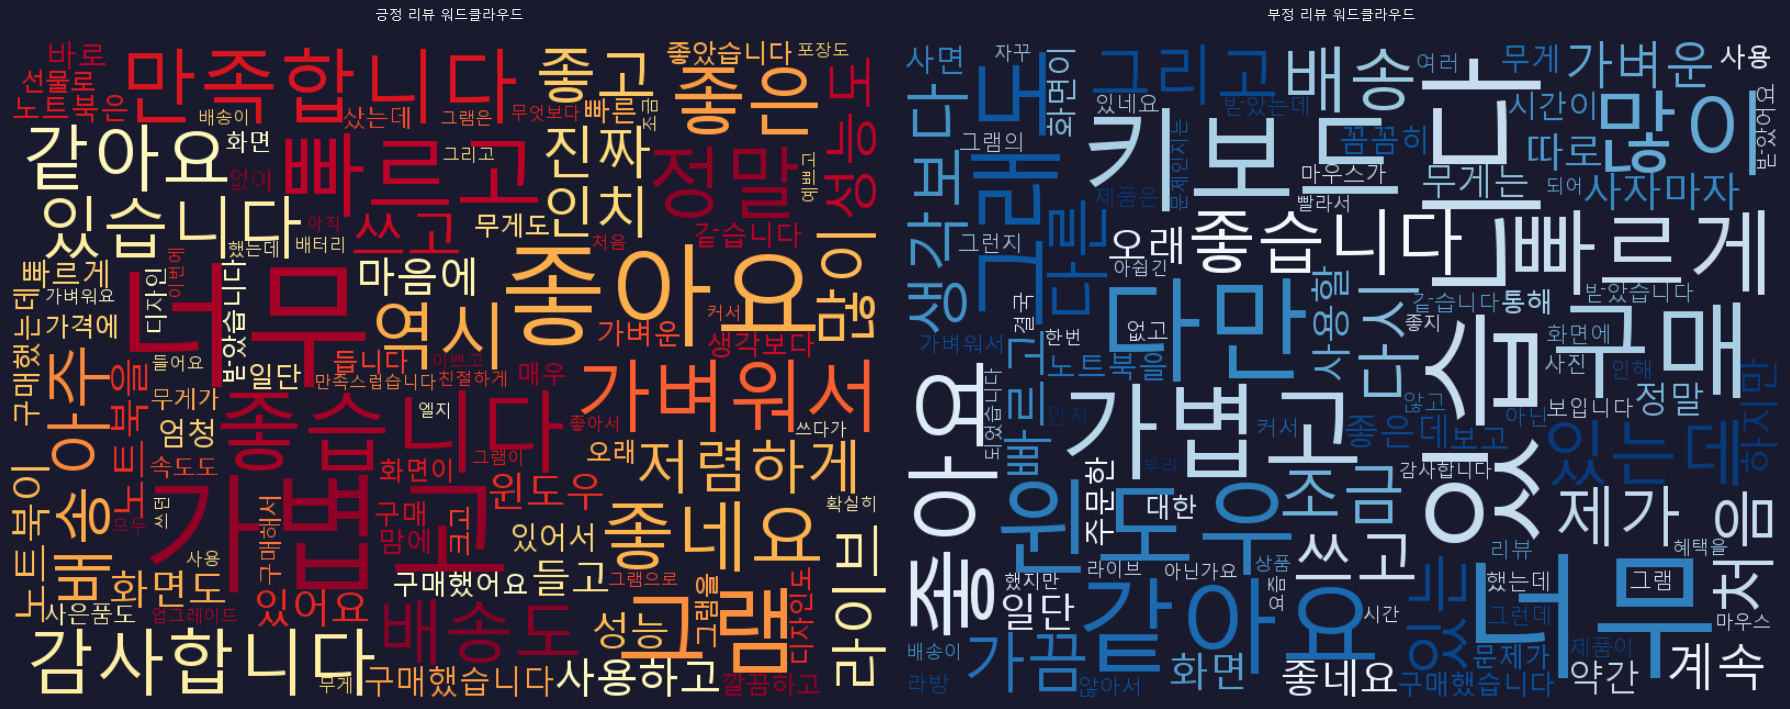

저장 완료!


In [7]:
font_path = 'C:/Windows/Fonts/malgun.ttf'

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#1a1a2e')

for ax, (counter, color, title) in zip(axes, [
    (positive_counter, 'YlOrRd', '긍정 리뷰 워드클라우드'),
    (negative_counter, 'Blues',  '부정 리뷰 워드클라우드')
]):
    wc = WordCloud(
        font_path=font_path,
        width=800, height=600,
        background_color='#1a1a2e',
        colormap=color,
        max_words=100,
        max_font_size=120,
        min_font_size=10
    ).generate_from_frequencies(counter)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=18, color='white', pad=15,
                 fontproperties=plt.matplotlib.font_manager.FontProperties(fname=font_path))

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("저장 완료!")

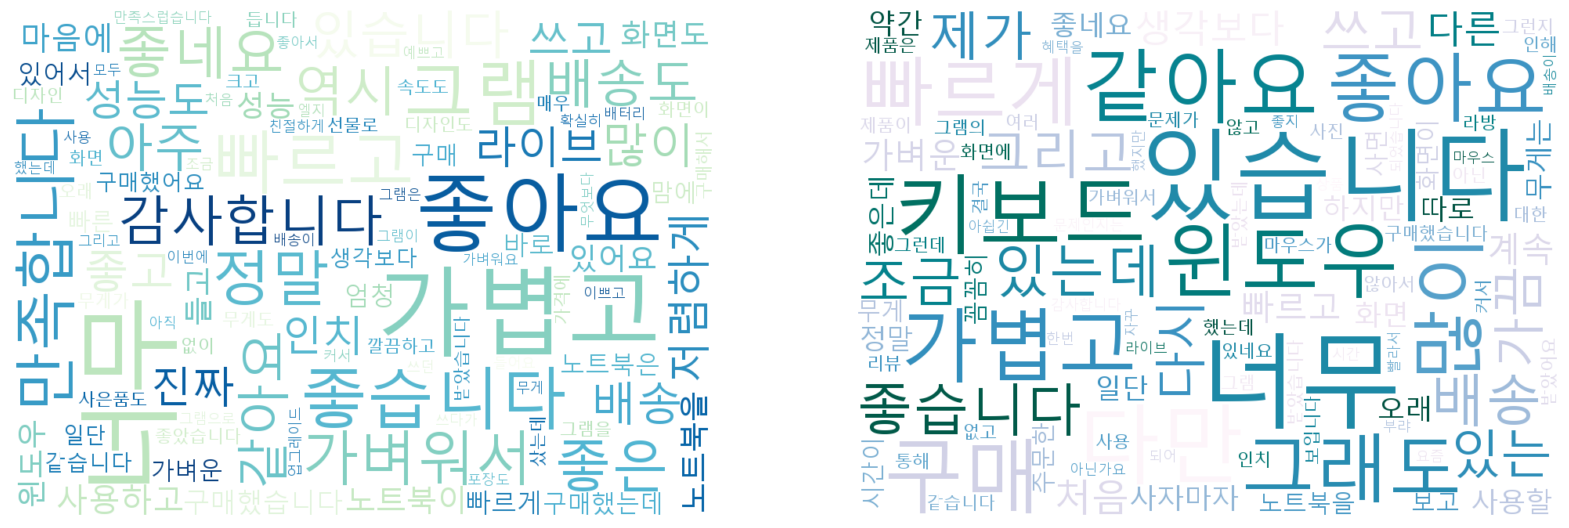

In [8]:
font_path = 'C:/Windows/Fonts/malgun.ttf'

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor('white')

configs = [
    (positive_counter, 'GnBu',    '긍정 리뷰 워드클라우드', '#2a9d8f'),   # 민트
    (negative_counter, 'PuBuGn',  '부정 리뷰 워드클라우드', '#457b9d'),   # 하늘
]

for ax, (counter, color, title, title_color) in zip(axes, configs):
    wc = WordCloud(
        font_path=font_path,
        width=900, height=650,
        background_color='white',
        colormap=color,
        max_words=100,
        max_font_size=130,
        min_font_size=10,
        prefer_horizontal=0.9,
        margin=5
    ).generate_from_frequencies(counter)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')

    # 제목

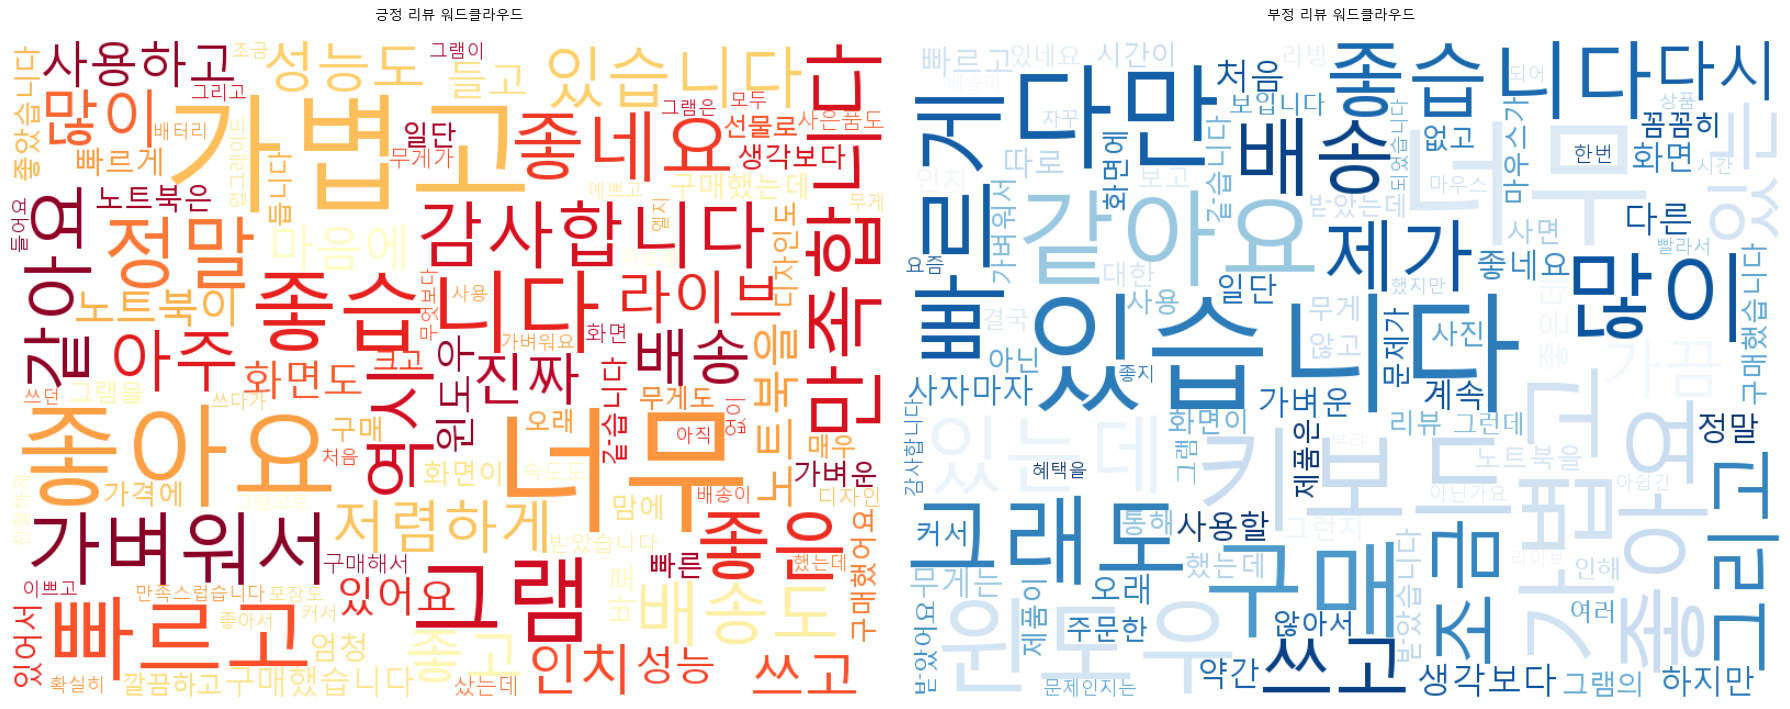

저장 완료!


In [9]:
font_path = 'C:/Windows/Fonts/malgun.ttf'

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')

for ax, (counter, color, title) in zip(axes, [
    (positive_counter, 'YlOrRd', '긍정 리뷰 워드클라우드'),
    (negative_counter, 'Blues',  '부정 리뷰 워드클라우드')
]):
    wc = WordCloud(
        font_path=font_path,
        width=800, height=600,
        background_color='white',
        colormap=color,
        max_words=100,
        max_font_size=120,
        min_font_size=10
    ).generate_from_frequencies(counter)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=18, color='black', pad=15,
                 fontproperties=plt.matplotlib.font_manager.FontProperties(fname=font_path))

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("저장 완료!")